# Vertical Depth Profiles and Life Stages

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module
import cbmaps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib import rcParams
import matplotlib.font_manager as fm


import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np


In [2]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

stages = utils.stages
stage_colors = {key: value['color'] for key, value in stages.items()}
stage_labels = {key: value['label'] for key, value in stages.items()}
stage_markers = {key: value['marker'] for key, value in stages.items()}
stage_duration = {key: value['duration'] for key, value in stages.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}


## Make LS Key

In [3]:
def load_custom_font(variant="Light"):
    """Load the specified Aptos font variant."""
    font_path = f"/Library/Fonts/Aptos-{variant}.ttf"
    try:
        aptos_font = fm.FontProperties(fname=font_path)
        print(f"Using font: {aptos_font.get_name()}")
        return aptos_font
    except Exception as e:
        print(f"Error loading font: {e}")
        return None  # Return None if font loading fails


def add_stage_rectangles(ax, stages, font):
    """Add stage rectangles and labels to the axes."""
    for i, (stage, info) in enumerate(stages.items()):
        # Create a colored rectangle for each stage
        rect = Rectangle((i * 2, 0.4), width=1.5, height=0.5, color=info['color'])
        ax.add_patch(rect)

        # Add the stage label and duration inside the rectangle
        ax.text(
            i * 2 + 0.75, 0.65, 
            f"{info['label']}\n({info['duration']})",
            va='center', ha='center', fontsize=40, fontproperties=font, color='white'
        )


def add_arrows_between_stages(ax, num_stages):
    """Add arrows between consecutive stages."""
    for i in range(num_stages - 1):
        arrow = FancyArrowPatch(
            (i * 2 + 1.5, 0.65), ((i + 1) * 2, 0.65),
            arrowstyle='->,head_width=0.5,head_length=0.7', linewidth=7,
            mutation_scale=25, color='black'
        )
        ax.add_patch(arrow)


def configure_and_save_plot(num_stages, save_path=None):
    """Configure plot layout and save if a path is provided."""
    fig, ax = plt.subplots(figsize=(num_stages * 4, 4))
    ax.set_xlim(0, num_stages * 2)
    ax.set_ylim(0, 1)
    ax.axis('off')  # Hide axes

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    return fig, ax

In [6]:
def plot_lifecycle_key(stages, font_variant="Light", save_path=None):
    """Main function to generate the lifecycle key."""
    # Load the custom font (or fallback to default)
    font = load_custom_font(font_variant)
    if font is None:
        print("Using default font as fallback.")

    num_stages = len(stages)

    # Configure plot
    fig, ax = configure_and_save_plot(num_stages)

    # Add stage rectangles and labels
    add_stage_rectangles(ax, stages, font)

    # Add arrows between stages
    add_arrows_between_stages(ax, num_stages)

    # Refresh and render the canvas to avoid blank outputs
    fig.canvas.draw()

    # Save the plot with a transparent background if a save path is provided
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    # Display the plot
    plt.show()

Using font: Aptos
Saved lifecycle key to Fig-Lib/lifecycle_key.png


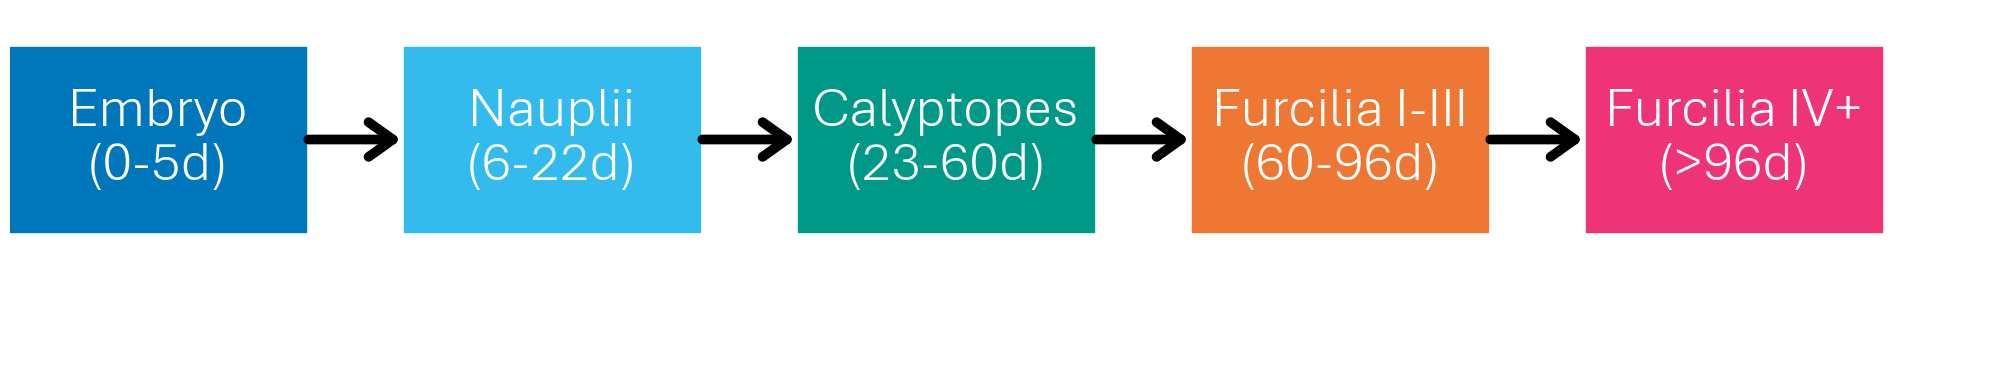

In [7]:
plot_lifecycle_key(stages, font_variant="Light", save_path="Fig-Lib/lifecycle_key.png")

## Make Depth Profile

In [57]:
import numpy as np

def generate_vertical_profile_data_ocean_only_dvm(duration=180):
    """
    Generate vertical profile data with sinking, ascent, and DVM phases 
    according to basic DVM rules for the ocean-only simulation.
    """
    release_depth = -5  # Release happens 5 meters below the surface
    sinking_rate = 145 / 24  # Convert sinking rate to m/hour
    ascent_rate = 68.2 / 24  # Convert ascent rate to m/hour
    dvm_velocity = 0.016 * 3600  # 0.016 m/s converted to m/hour
    dvm_start_hour = 63 * 24  # DVM starts after 63 days (in hours)
    surface_limit = -1.5  # DVM ascent stops within 1.5 m of the surface
    max_dvm_depth = -150  # DVM only applies above 150 m depth

    # Define sunrise and sunset in hours (4 AM to 10:45 PM = 6:00 to 22.75)
    sunrise_hour = 4  # 4 AM
    sunset_hour = 22.75  # 10:45 PM

    hours = np.arange(duration * 24)  # Generate hourly data
    depths = np.full_like(hours, release_depth, dtype=float)  # Initialize depths

    # Phase 1: Sinking (0-5 days or 120 hours)
    for hour in range(120):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (5-63 days or 121-1512 hours)
    ascent_start = 120
    ascent_end = dvm_start_hour
    for hour in range(ascent_start, ascent_end):
        previous_depth = depths[hour - 1]
        depths[hour] = min(previous_depth + ascent_rate, release_depth)

    # Phase 3: DVM (63-180 days)
    for hour in range(dvm_start_hour, duration * 24):
        # Determine if it's day or night based on the hour of the day
        local_hour = hour % 24
        is_daytime = sunrise_hour <= local_hour < sunset_hour

        current_depth = depths[hour - 1]

        if is_daytime and current_depth > max_dvm_depth:
            # During the day, descend with DVM velocity
            depths[hour] = max(current_depth - dvm_velocity, -800)
        elif not is_daytime and current_depth < surface_limit:
            # At night, ascend with DVM velocity
            depths[hour] = min(current_depth + dvm_velocity, surface_limit)
        else:
            # Maintain the current depth otherwise
            depths[hour] = current_depth

    # Convert hours to days for plotting
    days = hours / 24
    return days, depths

In [62]:
# Define the stage hour ranges for the full 180-day profile
stage_hour_ranges = {
    0: (0, 120),         # Embryo: 0–120 hours (0–5 days)
    1: (121, 528),       # Nauplii: 121–528 hours (6–22 days)
    2: (529, 1440),      # Calyptopes: 529–1440 hours (23–60 days)
    3: (1441, 2304),     # Furcilia I–III: 1441–2304 hours (61–96 days)
    4: (2303, 4320)      # Furcilia IV+: 2305–4320 hours (97–180 days)
}

In [171]:
def plot_vertical_profile(days, depths, stage_colors, stage_hour_ranges, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 5))  # Adjusted size to 10x6
    ax.set_title("Standard Descent-Ascent Cycle with Standard DVM Pattern", fontsize=16)

    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        # Convert hours to days for indexing the data
        start_day = start_hour / 24
        end_day = end_hour / 24

        # Find the indices corresponding to the stage's time span
        start_idx = max(0, np.searchsorted(days, start_day))
        end_idx = min(len(days), np.searchsorted(days, end_day))

        # Plot this segment with the corresponding color
        ax.plot(
            days[start_idx:end_idx], depths[start_idx:end_idx], 
            color=stage_colors[stage], linewidth=3, label=stages[stage]['label']
        )

    # Set axis labels
    ax.set_xlabel('Days since release', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Invert the y-axis so 0 m (surface) is at the top
    ax.set_ylim(-800, 5)
    # Set x-axis limit to match the total duration in days
    ax.set_xlim(-0.5, 120)
    # Adjust tick label sizes
    ax.tick_params(axis='x', labelsize=14)  # X-axis tick labels
    ax.tick_params(axis='y', labelsize=14)  # Y-axis tick labels
    # Add a legend for life stages
    ax.legend(loc='best', title='Life Stages', fontsize=10)

    # Adjust the layout for aesthetics
    plt.tight_layout()

    # # Optional: Add gridlines for clarity
    # ax.grid(True, linestyle='--', alpha=0.5)

    # # Save the plot if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"Plot saved to {save_path}")

    # Show the plot
    plt.show()


Plot saved to Fig-Lib/vert-profs/depth-profile-ls-color_h_null.png


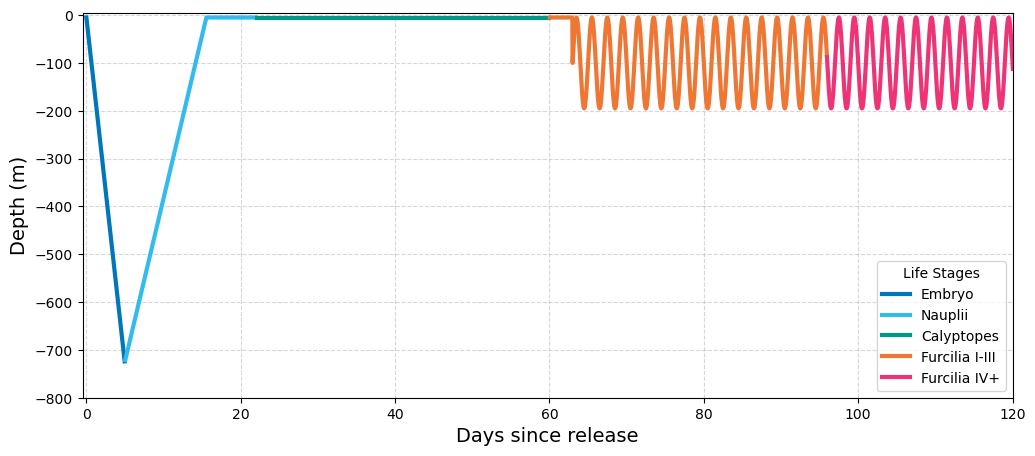

In [64]:
# Hypothesis Vertical Profile:
hyp = 'h_null'

# Generate the vertical profile data
days, depths = generate_vertical_profile_data(duration=180)

# Plot the profile with color-coded life stages
plot_vertical_profile_colored(
    days, depths, stage_colors, stage_hour_ranges, save_path=f"Fig-Lib/vert-profs/depth-profile-ls-color_{hyp}.png")

So what I am doing with this plot is making a demonstrative plot of complex beahvior within our model. What we create will be a figure for the methods section. In that section I want to show a simplified version of the basic DVM behavior that we defined as follows:


DVM was based on the local solar angle at the position of the drifter: 
when the sun is above the horizon a downward velocity (0.016 m s-1; Hudson et al., 2022) is added to the advective and random vertical velocities if the drifter is above 150 m depth (Hudson et al., 2022). 
Once the sun goes below the horizon, an upward velocity (0.016 m s-1) is added to all other vertical velocities until the drifter is within 1.5 m of the surface. The simulated DVM is continued for the remainder of the simulation.

In [163]:
def generate_vertical_profile_data_dvm(duration=180):
    release_depth = -5  # 5 meters below the surface
    sinking_rate = 145  # m/day
    initial_sinking_time = 120 / 24  # 120 hours = 5 days
    ascent_rate = 68.2  # m/day
    dvm_start_day = 63  # DVM starts on day 63

    # Time variables
    hours = np.arange(duration * 24)  # Generate data in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Initialize at release depth

    # Constants for DVM
    dvm_velocity = 0.016 * 3600  # Convert to meters per hour
    sunrise_hour = 4  # 4:00 AM
    sunset_hour = 22 + 45 / 60  # 10:45 PM

    # Phase 1: Sinking (0-5 days)
    for hour in range(int(initial_sinking_time * 24)):
        depths[hour] = max(release_depth - hour * (sinking_rate / 24), -800)

    # Phase 2: Ascent (5-63 days)
    ascent_start = int(initial_sinking_time * 24)
    for hour in range(ascent_start, dvm_start_day * 24):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * (ascent_rate / 24), release_depth)

    # Phase 3: DVM (63-180 days)
    for hour in range(dvm_start_day * 24, duration * 24):
        day_fraction = (hour % 24)  # Hour within the day (0–23)

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Move downward if above 150m
            if depths[hour - 1] > -150:
                depths[hour] = depths[hour - 1] - dvm_velocity
            else:
                depths[hour] = depths[hour - 1]  # Stay at -150m if below
        else:  # Nighttime: Move upward until within 1.5m of the surface
            if depths[hour - 1] < -1.5:
                depths[hour] = depths[hour - 1] + dvm_velocity
            else:
                depths[hour] = depths[hour - 1]  # Stay near surface

    # Convert hours to days for plotting
    days = hours / 24
    return days, depths


Plot saved to Fig-Lib/vert-profs/depth-profile-ls-color_h_null-DVM.png


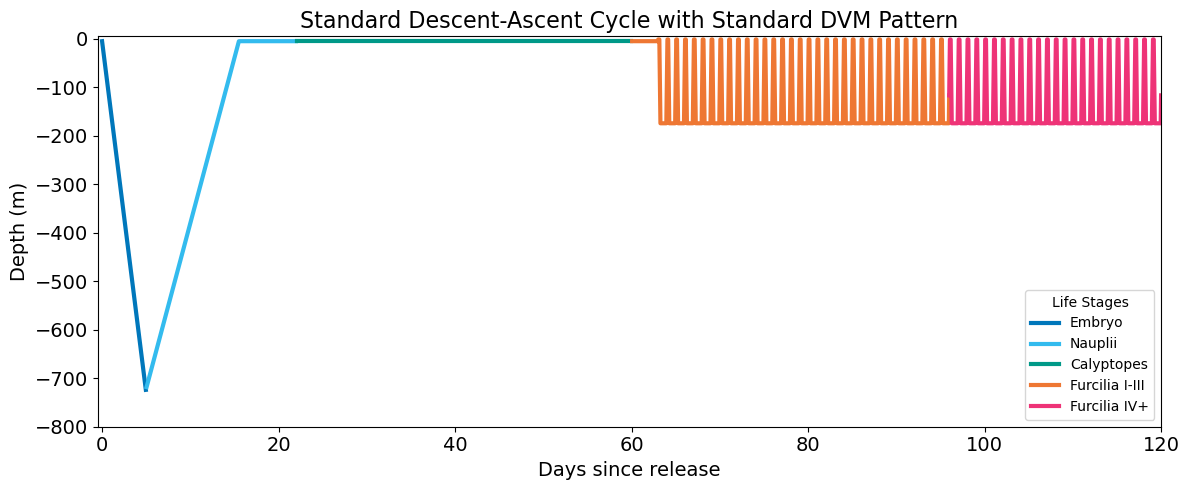

In [172]:
# Hypothesis Vertical Profile:
hyp = 'h_null'

# # Generate the vertical profile data
# days, depths = generate_vertical_profile_data_dvm(duration=121)

# # Plot the profile with color-coded life stages
# plot_vertical_profile_colored(
#     days, depths, stage_colors, stage_hour_ranges, save_path=f"Fig-Lib/vert-profs/depth-profile-ls-color_{hyp}-DVM.png")


# Generate the data
normal_days, normal_depths = generate_vertical_profile_data_ocean_only_dvm(duration=120)

# Plot the comparison with horizontal arrows indicating SIC change
plot_vertical_profile(
    normal_days, normal_depths,stage_colors, stage_hour_ranges, save_path=f"Fig-Lib/vert-profs/depth-profile-ls-color_{hyp}-DVM.png")

sea ice?

In [137]:
import numpy as np

def generate_vertical_profile_data_modified_dvm(duration=180, sea_ice_conc_fn=None):
    """
    Generate vertical profile data with switching between regular and reverse DVM 
    based on sea ice concentration.
    """
    # Parameters
    release_depth = -5  # 5 meters below the surface
    sinking_rate = 145 / 24  # m/hour
    initial_sinking_time = 120  # hours (5 days)
    ascent_rate = 68.2 / 24  # m/hour
    dvm_start_hour = 63 * 24  # DVM starts after 63 days

    dvm_velocity = 0.016 * 3600  # Convert 0.016 m/s to m/hour
    surface_limit = -1.5  # Near-surface limit
    max_dvm_depth = -200  # Max depth for regular DVM
    reverse_dvm_depth = -20  # Max depth for reverse DVM under sea ice

    sunrise_hour = 4  # 4:00 AM
    sunset_hour = 22.75  # 10:45 PM

    # Generate hourly data
    hours = np.arange(duration * 24)
    depths = np.full_like(hours, release_depth, dtype=float)  # Initialize at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (120–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[hour - 1] + ascent_rate, release_depth)

    # Phase 3: Regular or Reverse DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        sea_ice_conc = sea_ice_conc_fn(hour) if sea_ice_conc_fn else 0
        day_fraction = hour % 24  # Current hour of the day (0–23)

        if sea_ice_conc >= 0.25:  # Reverse DVM under sea ice
            if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Move upward
                if depths[hour - 1] > surface_limit:
                    depths[hour] = depths[hour - 1] + dvm_velocity
                else:
                    depths[hour] = surface_limit  # Stay near the surface
            else:  # Nighttime: Move downward
                if depths[hour - 1] > reverse_dvm_depth:
                    depths[hour] = depths[hour - 1] - dvm_velocity
                else:
                    depths[hour] = reverse_dvm_depth  # Stay at -20m

        else:  # Regular DVM
            if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Move downward
                if depths[hour - 1] > max_dvm_depth:
                    depths[hour] = depths[hour - 1] - dvm_velocity
                else:
                    depths[hour] = max_dvm_depth  # Stay at -200m
            else:  # Nighttime: Move upward
                if depths[hour - 1] < surface_limit:
                    depths[hour] = depths[hour - 1] + dvm_velocity
                else:
                    depths[hour] = surface_limit  # Stay near the surface

    # Convert hours to days for plotting
    days = hours / 24
    return days, depths

### attemot 

Comparison plot saved to vertical_profile_dvm_comparison_with_arrows.png


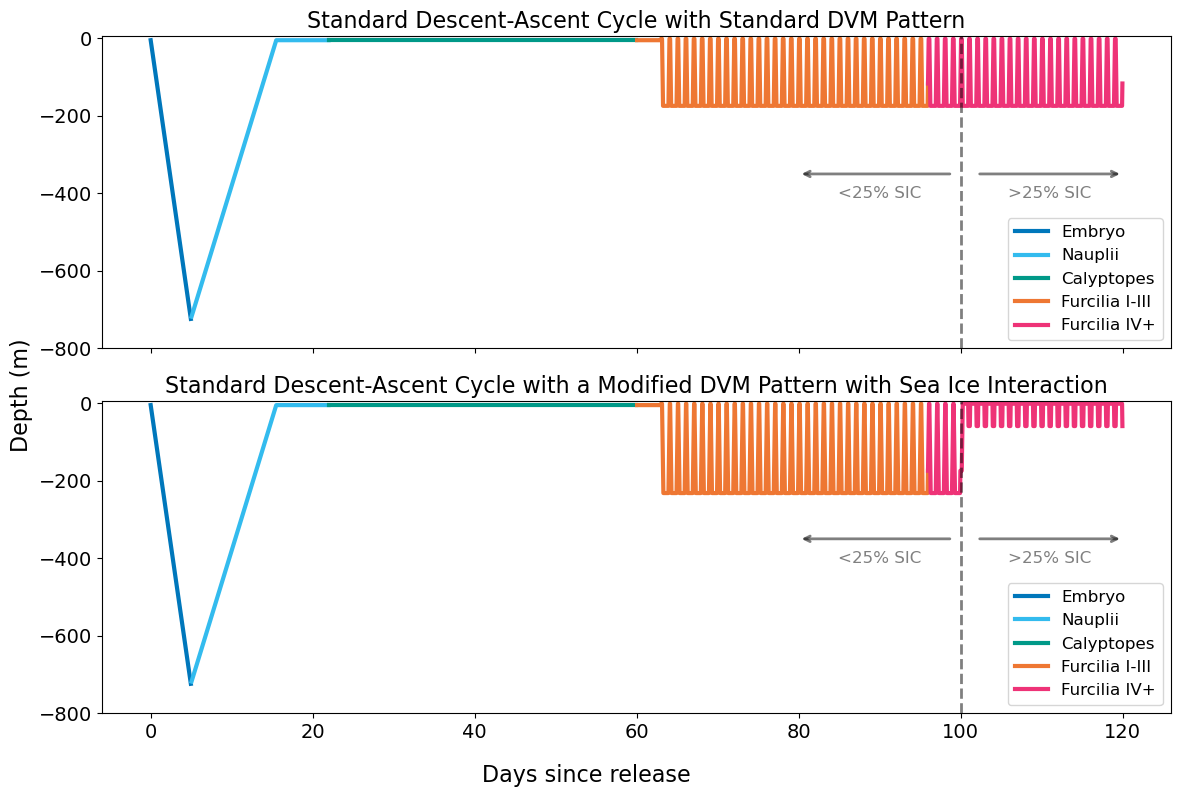

In [147]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dual_vertical_profiles_with_horizontal_arrows(
    normal_days, normal_depths, modified_days, modified_depths, 
    stage_colors, stage_hour_ranges, save_path=None
):
    """Plot normal and modified DVM vertical profiles with horizontal arrows for SIC change."""

    fig, axes = plt.subplots(nrows=2, figsize=(12, 8), sharex=True, sharey=True)

    # Plot Normal DVM
    axes[0].set_title("Standard Descent-Ascent Cycle with Standard DVM Pattern", fontsize=16)
    plot_vertical_profile_on_ax(axes[0], normal_days, normal_depths, stage_colors, stage_hour_ranges)

    # Plot Modified DVM with Sea Ice Interaction
    axes[1].set_title("Standard Descent-Ascent Cycle with a Modified DVM Pattern with Sea Ice Interaction", fontsize=16)
    plot_vertical_profile_on_ax(axes[1], modified_days, modified_depths, stage_colors, stage_hour_ranges)

    # Add vertical line at day 100
    for ax in axes:
        ax.axvline(x=100, color='black', linestyle='--', linewidth=2, alpha=0.5)

    # Add horizontal arrow pointing right at day 120 with text above
    for ax in axes:
        # Horizontal arrow
        ax.annotate(
            "", xy=(120, -350), xytext=(102, -350),
            arrowprops=dict(arrowstyle='->', lw=2, color='black', alpha=0.5)
        )

        # Text above the arrow
        ax.text(
            111, -400, ">25% SIC", fontsize=12, ha='center', va='center', 
            color='gray'
        )

    # Add horizontal arrow pointing left at day 90 with text above
    for ax in axes:
        # Horizontal arrow
        ax.annotate(
            "", xy=(80, -350), xytext=(99, -350),
            arrowprops=dict(arrowstyle='->', lw=2, color='black', alpha=0.5)
        )

        # Text above the arrow
        ax.text(
            90, -400, "<25% SIC", fontsize=12, ha='center', va='center', 
            color='gray'
        )
    # Set common axis labels with larger fonts
    fig.supxlabel("Days since release", fontsize=16)  # Adjust size here
    fig.supylabel("Depth (m)", fontsize=16)  # Adjust size here

    # Adjust tick label sizes
    for ax in axes:
        ax.tick_params(axis='x', labelsize=14)  # X-axis tick labels
        ax.tick_params(axis='y', labelsize=14)  # Y-axis tick labels

    # Adjust the layout for aesthetics
    plt.tight_layout()

    # Save the plot if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"Comparison plot saved to {save_path}")

    # Show the plot
    plt.show()

def plot_vertical_profile_on_ax(ax, days, depths, stage_colors, stage_hour_ranges):
    """Helper function to plot a vertical profile on a given axis."""
    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        # Convert hours to days for indexing
        start_day = start_hour / 24
        end_day = end_hour / 24

        # Find the indices corresponding to the stage's time span
        start_idx = max(0, np.searchsorted(days, start_day))
        end_idx = min(len(days), np.searchsorted(days, end_day))

        # Plot this segment with the corresponding color
        ax.plot(
            days[start_idx:end_idx], depths[start_idx:end_idx], 
            color=stage_colors[stage], linewidth=3, label=stages[stage]['label']
        )

    # Customize the axis
    ax.set_ylim(-800, 5)  # Surface at the top, depths at the bottom
    # ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='lower right', fontsize=12)#, title="Life Stage")

# Generate the data
normal_days, normal_depths = generate_vertical_profile_data_ocean_only_dvm(duration=120)
modified_days, modified_depths = generate_vertical_profile_data_with_sea_ice(
    duration=120, sea_ice_conc_fn=lambda hour: 0 if hour < 2400 else 0.5
)

# Plot the comparison with horizontal arrows indicating SIC change
plot_dual_vertical_profiles_with_horizontal_arrows(
    normal_days, normal_depths, modified_days, modified_depths,
    stage_colors, stage_hour_ranges, save_path="vertical_profile_dvm_comparison_with_arrows.png"
)

In [160]:

def plot_vertical_profile_on_ax_no_leg(ax, days, depths, stage_colors, stage_hour_ranges):
    """Helper function to plot a vertical profile on a given axis."""
    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        # Convert hours to days for indexing
        start_day = start_hour / 24
        end_day = end_hour / 24

        # Find the indices corresponding to the stage's time span
        start_idx = max(0, np.searchsorted(days, start_day))
        end_idx = min(len(days), np.searchsorted(days, end_day))

        # Plot this segment with the corresponding color
        ax.plot(
            days[start_idx:end_idx], depths[start_idx:end_idx], 
            color=stage_colors[stage], linewidth=3, label=stages[stage]['label']
        )

    # Customize the axis
    ax.set_ylim(-800, 5)  # Surface at the top, depths at the bottom



Zoomed-in plot saved to Fig-Lib/vert-profs/zoomed_dvm_profile_comparison-95d-105d.png


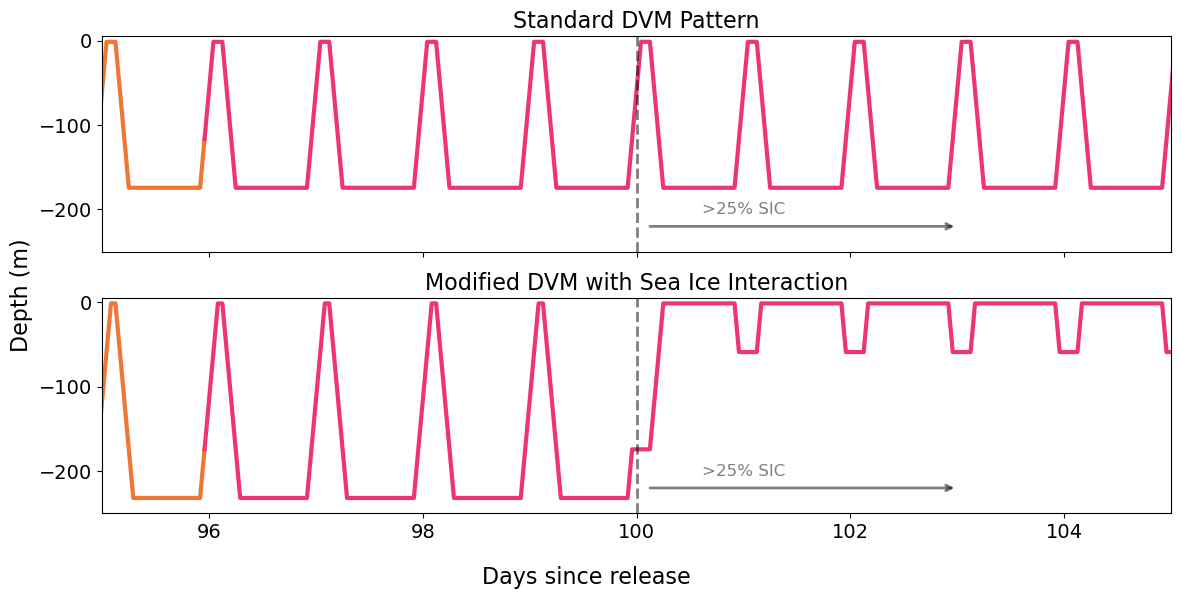

In [175]:
def plot_dual_vertical_profiles_with_horizontal_arrows_zoomed(
    normal_days, normal_depths, modified_days, modified_depths, 
    stage_colors, stage_hour_ranges, zoom_xlim=(95, 105), zoom_ylim=(-250, 5), 
    save_path=None
):
    """Plot zoomed-in normal and modified DVM vertical profiles with horizontal arrows."""

    fig, axes = plt.subplots(nrows=2, figsize=(12, 6), sharex=True, sharey=True)

    # Plot Normal DVM
    axes[0].set_title("Standard DVM Pattern", fontsize=16)
    plot_vertical_profile_on_ax_no_leg(axes[0], normal_days, normal_depths, stage_colors, stage_hour_ranges)

    # Plot Modified DVM with Sea Ice Interaction
    axes[1].set_title("Modified DVM with Sea Ice Interaction", fontsize=16)
    plot_vertical_profile_on_ax_no_leg(axes[1], modified_days, modified_depths, stage_colors, stage_hour_ranges)

    # Add vertical line at day 100 for context
    for ax in axes:
        ax.axvline(x=100, color='black', linestyle='--', linewidth=2, alpha=0.5)

    # Add horizontal arrow pointing right at day 120 with text above
    for ax in axes:
        ax.annotate(
            "", xy=(103, -220), xytext=(100.1, -220),
            arrowprops=dict(arrowstyle='->', lw=2, color='black', alpha=0.5)
        )
        ax.text(
            101, -200, ">25% SIC", fontsize=12, ha='center', va='center', color='gray'
        )

    # Set zoomed-in axis limits
    for ax in axes:
        ax.set_xlim(zoom_xlim)  # Zoom in on the x-axis (days)
        ax.set_ylim(zoom_ylim)  # Zoom in on the y-axis (depths)

    # Set common axis labels with larger fonts
    fig.supxlabel("Days since release", fontsize=16)
    fig.supylabel("Depth (m)", fontsize=16)

    # Adjust tick label sizes
    for ax in axes:
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

    # Adjust the layout for aesthetics
    plt.tight_layout()

    # Save the plot if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"Zoomed-in plot saved to {save_path}")

    # Show the plot
    plt.show()

# Generate the data
normal_days, normal_depths = generate_vertical_profile_data_ocean_only_dvm(duration=120)
modified_days, modified_depths = generate_vertical_profile_data_with_sea_ice(
    duration=120, sea_ice_conc_fn=lambda hour: 0 if hour < 2400 else 0.5
)

# Plot the zoomed-in comparison with horizontal arrows indicating SIC change
plot_dual_vertical_profiles_with_horizontal_arrows_zoomed(
    normal_days, normal_depths, modified_days, modified_depths,
    stage_colors, stage_hour_ranges, zoom_xlim=(95, 105), zoom_ylim=(-250, 5),
    save_path="Fig-Lib/vert-profs/zoomed_dvm_profile_comparison-95d-105d.png")

In [140]:
import numpy as np

def generate_vertical_profile_data_with_sea_ice(duration=180, sea_ice_conc_fn=None):
    """
    Generate vertical profile data that switches between regular and reverse DVM 
    based on sea ice concentration at each hour.
    """
    # Shared parameters
    release_depth = -5  # 5 meters below the surface
    sinking_rate = 145 / 24  # m/hour
    ascent_rate = 68.2 / 24  # m/hour
    dvm_velocity = 0.016 * 3600  # 0.016 m/s converted to m/hour
    dvm_start_hour = 63 * 24  # DVM starts after 63 days in hours
    surface_limit = -1.5  # Stop ascent near the surface
    max_regular_dvm_depth = -200  # Regular DVM max depth
    max_reverse_dvm_depth = -20  # Reverse DVM max depth

    # Sunrise and sunset hours for DVM
    sunrise_hour = 4  # 4:00 AM
    sunset_hour = 22.75  # 10:45 PM

    # Generate hourly data
    hours = np.arange(duration * 24)
    depths = np.full_like(hours, release_depth, dtype=float)

    # Phase 1: Sinking (0–120 hours)
    for hour in range(120):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    for hour in range(120, dvm_start_hour):
        depths[hour] = min(depths[hour - 1] + ascent_rate, release_depth)

    # Phase 3: DVM with sea ice interaction (1512–end)
    for hour in range(dvm_start_hour, duration * 24):
        sea_ice_conc = sea_ice_conc_fn(hour) if sea_ice_conc_fn else 0
        current_depth = depths[hour - 1]
        local_hour = hour % 24  # Determine hour of the day
        is_daytime = sunrise_hour <= local_hour < sunset_hour

        if sea_ice_conc >= 0.25:
            # Reverse DVM behavior under sea ice
            if is_daytime and current_depth < surface_limit:
                # Ascend during the day (reverse behavior)
                depths[hour] = min(current_depth + dvm_velocity, surface_limit)
            elif not is_daytime and current_depth > max_reverse_dvm_depth:
                # Descend at night (reverse behavior)
                depths[hour] = max(current_depth - dvm_velocity, -800)
            else:
                depths[hour] = current_depth  # Maintain current depth
        else:
            # Regular DVM behavior without sea ice
            if is_daytime and current_depth > max_regular_dvm_depth:
                # Descend during the day
                depths[hour] = max(current_depth - dvm_velocity, -800)
            elif not is_daytime and current_depth < surface_limit:
                # Ascend at night
                depths[hour] = min(current_depth + dvm_velocity, surface_limit)
            else:
                depths[hour] = current_depth  # Maintain current depth

    # Convert hours to days for plotting
    days = hours / 24
    return days, depths

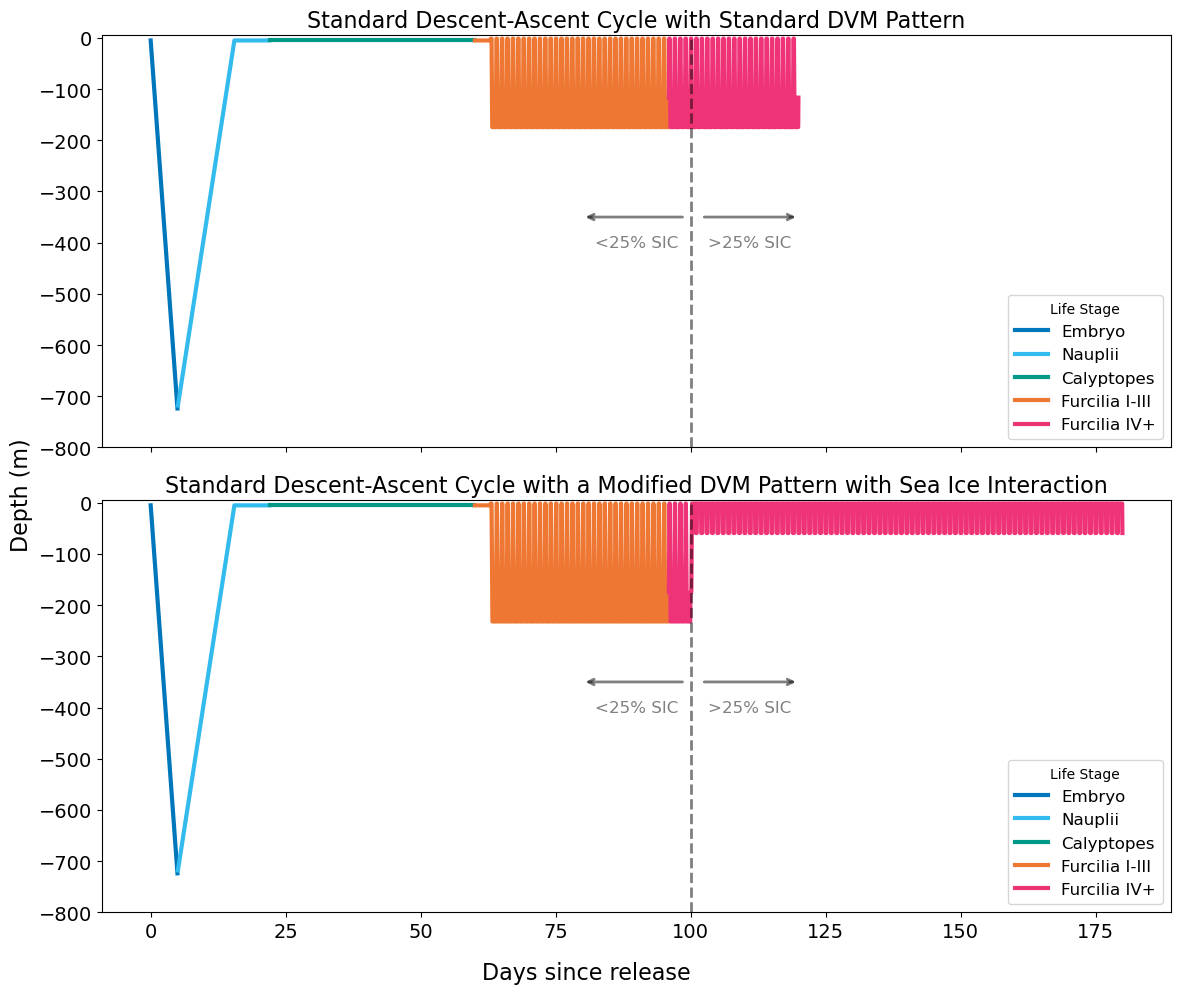

In [141]:
def mock_sea_ice_concentration(hour):
    """Sea ice concentration: 0% before 100 days, 50% after 100 days."""
    return 0 if hour < 100 * 24 else 0.5

# Generate data for plotting
days, depths = generate_vertical_profile_data_with_sea_ice(
    duration=180, sea_ice_conc_fn=mock_sea_ice_concentration
)

# Plot the profile to verify behavior
plot_dual_vertical_profiles_with_horizontal_arrows(
    normal_days, normal_depths, days, depths,
    stage_colors, stage_hour_ranges)#, save_path="corrected_dvm_profile.png"
